In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and splitting
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [2]:
# Load the parquet files
train_df = pd.read_parquet('../data/UNSW/UNSW_NB15_training-set.parquet')
test_df = pd.read_parquet('../data/UNSW/UNSW_NB15_testing-set.parquet')

print("="*60)
print(" DATASET OVERVIEW")
print("="*60)
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nTotal records: {len(train_df) + len(test_df)}")

FileNotFoundError: [Errno 2] No such file or directory: '../data/UNSW/UNSW_NB15_training-set.parquet'

In [3]:
import os
print("Current working directory:", os.getcwd())
print("\nContents of data/UNSW folder:")
print(os.listdir('../data/UNSW'))

Current working directory: C:\xampp\htdocs\group16

Contents of data/UNSW folder:


FileNotFoundError: [WinError 3] The system cannot find the path specified: '../data/UNSW'

In [4]:
import os
print("Current directory:", os.getcwd())
print("\nContents of 'data' folder:")
if os.path.exists('../data'):
    print(os.listdir('../data'))
else:
    print("❌ 'data' folder not found!")
    
print("\nContents of current directory:")
print(os.listdir('.'))

Current directory: C:\xampp\htdocs\group16

Contents of 'data' folder:
❌ 'data' folder not found!

Contents of current directory:
['.ipynb_checkpoints', '01_data_exploration.ipynb', '01_UNSW_Exploration.ipynb', '02_data_preprocessing.ipynb', '03_feature_selection.ipynb', '04_model_building.ipynb', '05_model_evaluation.ipynb', 'data', 'debug_model_input.py', 'detect_attack.py', 'diagnose_model.py', 'models', 'notebooks', 'proper_detect.py', 'README.md', 'requirements.txt', 'results', 'sample_traffic.csv', 'simple_detect.py', 'simple_test.py', 'src']


In [5]:
# Load the parquet files - USING CORRECT PATH
train_df = pd.read_parquet('data/UNSW/UNSW_NB15_training-set.parquet')
test_df = pd.read_parquet('data/UNSW/UNSW_NB15_testing-set.parquet')

print("="*60)
print(" DATASET OVERVIEW")
print("="*60)
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"\nTotal records: {len(train_df) + len(test_df)}")

 DATASET OVERVIEW
Training set shape: (175341, 36)
Test set shape: (82332, 36)

Total records: 257673


 CURRENT DATA SPLIT
Training set: 175,341 records (68.0%)
Test set: 82,332 records (32.0%)


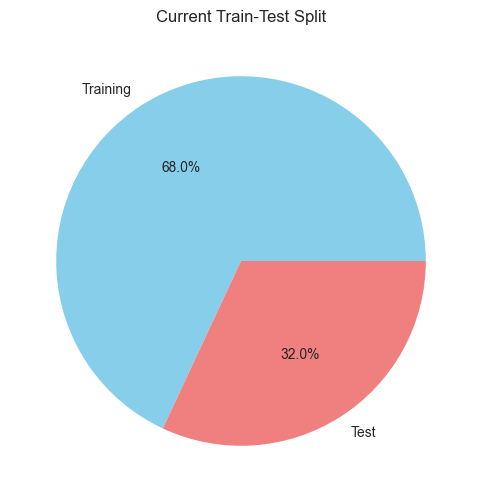

In [6]:
# Calculate current split
total = len(train_df) + len(test_df)
train_pct = (len(train_df) / total) * 100
test_pct = (len(test_df) / total) * 100

print("="*60)
print(" CURRENT DATA SPLIT")
print("="*60)
print(f"Training set: {len(train_df):,} records ({train_pct:.1f}%)")
print(f"Test set: {len(test_df):,} records ({test_pct:.1f}%)")

# Visualize
plt.figure(figsize=(6, 6))
plt.pie([len(train_df), len(test_df)], 
        labels=['Training', 'Test'],
        autopct='%1.1f%%',
        colors=['skyblue', 'lightcoral'])
plt.title('Current Train-Test Split')
plt.show()

In [7]:
print("="*60)
print(" LABEL DISTRIBUTION")
print("="*60)

# Check binary labels (0=normal, 1=attack)
train_normal = sum(train_df['label'] == 0)
train_attack = sum(train_df['label'] == 1)
test_normal = sum(test_df['label'] == 0)
test_attack = sum(test_df['label'] == 1)

print("TRAINING SET:")
print(f"  Normal: {train_normal:,} ({train_normal/len(train_df)*100:.1f}%)")
print(f"  Attack: {train_attack:,} ({train_attack/len(train_df)*100:.1f}%)")

print("\nTEST SET:")
print(f"  Normal: {test_normal:,} ({test_normal/len(test_df)*100:.1f}%)")
print(f"  Attack: {test_attack:,} ({test_attack/len(test_df)*100:.1f}%)")

 LABEL DISTRIBUTION
TRAINING SET:
  Normal: 56,000 (31.9%)
  Attack: 119,341 (68.1%)

TEST SET:
  Normal: 37,000 (44.9%)
  Attack: 45,332 (55.1%)


 ATTACK CATEGORIES
TRAINING SET - Attack types:
attack_cat
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Normal                0
Name: count, dtype: int64

TEST SET - Attack types:
attack_cat
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Normal                0
Name: count, dtype: int64


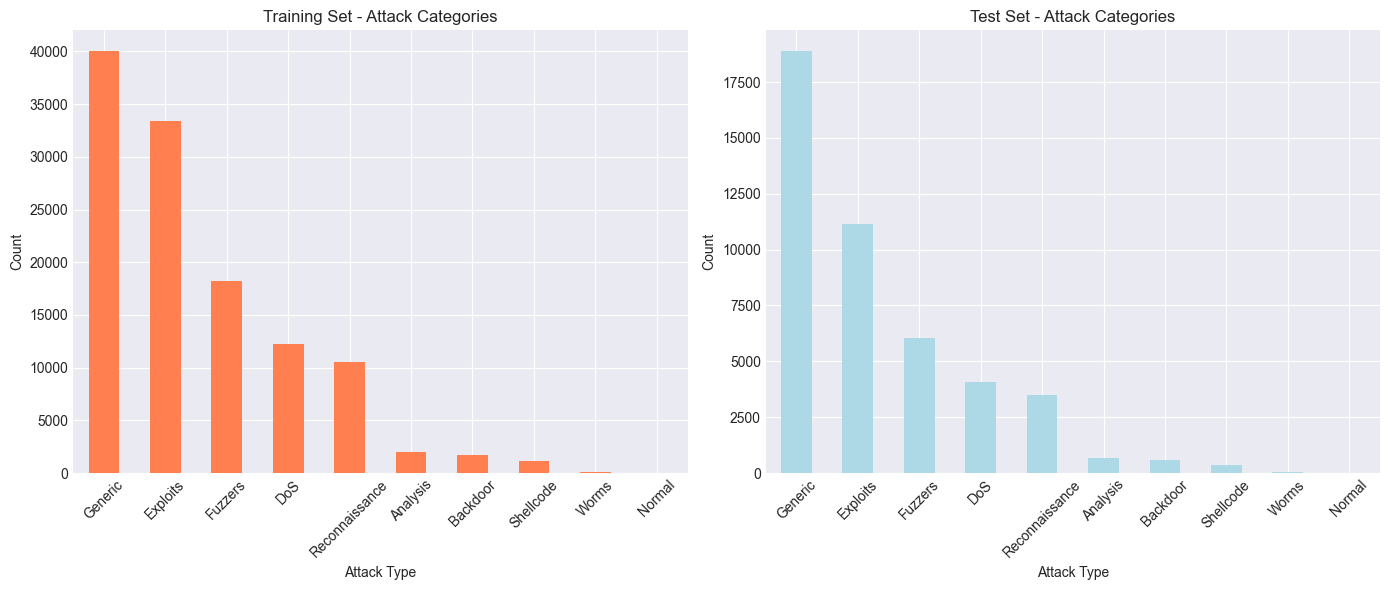

In [8]:
print("="*60)
print(" ATTACK CATEGORIES")
print("="*60)

# Training set attack categories
train_attacks = train_df[train_df['label'] == 1]['attack_cat'].value_counts()
test_attacks = test_df[test_df['label'] == 1]['attack_cat'].value_counts()

print("TRAINING SET - Attack types:")
print(train_attacks)

print("\nTEST SET - Attack types:")
print(test_attacks)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training
train_attacks.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Training Set - Attack Categories')
axes[0].set_xlabel('Attack Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Test
test_attacks.plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('Test Set - Attack Categories')
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
print("="*60)
print("CREATING 70/30 TRAIN-VALIDATION SPLIT")
print("="*60)

from sklearn.model_selection import train_test_split

# Separate features and labels from training set
X_train_full = train_df.drop(['label', 'attack_cat'], axis=1)  # Features
y_train_full = train_df['label']  # Binary labels

# Split into 70% train, 30% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, 
    y_train_full,
    test_size=0.3,  # 30% for validation
    random_state=42,
    stratify=y_train_full  # Maintains class balance
)

print(f"Original training set size: {len(X_train_full)}")
print(f"New training set size: {len(X_train)} ({len(X_train)/len(X_train_full)*100:.1f}%)")
print(f"Validation set size: {len(X_val)} ({len(X_val)/len(X_train_full)*100:.1f}%)")
print(f"Test set size: {len(test_df)} (unchanged)")

# Verify the split maintained class balance
print("\n VERIFYING CLASS BALANCE:")
print("\nTraining set:")
print(f"  Normal: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Attack: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

print("\nValidation set:")
print(f"  Normal: {sum(y_val==0)} ({sum(y_val==0)/len(y_val)*100:.1f}%)")
print(f"  Attack: {sum(y_val==1)} ({sum(y_val==1)/len(y_val)*100:.1f}%)")

CREATING 70/30 TRAIN-VALIDATION SPLIT
Original training set size: 175341
New training set size: 122738 (70.0%)
Validation set size: 52603 (30.0%)
Test set size: 82332 (unchanged)

 VERIFYING CLASS BALANCE:

Training set:
  Normal: 39200 (31.9%)
  Attack: 83538 (68.1%)

Validation set:
  Normal: 16800 (31.9%)
  Attack: 35803 (68.1%)


In [21]:
# ============================================================
# CREATE PROCESSED FOLDER IF IT DOESN'T EXIST
# ============================================================
import os

# Create the processed folder path
processed_path = '../data/processed'

# Check if folder exists, if not create it
if not os.path.exists(processed_path):
    os.makedirs(processed_path)
    print(f"Created folder: {processed_path}")
else:
    print(f"Folder already exists: {processed_path}")

# Verify we can write to it
test_file = f'{processed_path}/test.txt'
try:
    with open(test_file, 'w') as f:
        f.write('test')
    os.remove(test_file)
    print("Folder is writable")
except Exception as e:
    print(f"Cannot write to folder: {e}")

Created folder: ../data/processed
Folder is writable


In [24]:
# ============================================================
# CREATE X_test FROM test_df
# ============================================================
print("="*60)
print(" CREATING X_test FROM TEST DATA")
print("="*60)

# Create X_test by dropping label and attack_cat from test_df
X_test = test_df.drop(['label', 'attack_cat'], axis=1)
y_test = test_df['label']

print(f" X_test created with shape: {X_test.shape}")
print(f" y_test created with shape: {y_test.shape}")
print(f"   Features: {list(X_test.columns[:5])}...")

 CREATING X_test FROM TEST DATA
 X_test created with shape: (82332, 34)
 y_test created with shape: (82332,)
   Features: ['dur', 'proto', 'service', 'state', 'spkts']...


In [25]:
# ============================================================
# SAVE THE SPLIT DATA FOR PREPROCESSING
# ============================================================
print("="*60)
print("SAVING TRAIN/VAL/TEST SPLIT")
print("="*60)

# Save features
X_train.to_csv('../data/processed/UNSW_X_train.csv', index=False)
X_val.to_csv('../data/processed/UNSW_X_val.csv', index=False)
X_test.to_csv('../data/processed/UNSW_X_test.csv', index=False)

# Save labels
pd.DataFrame(y_train).to_csv('../data/processed/UNSW_y_train.csv', index=False)
pd.DataFrame(y_val).to_csv('../data/processed/UNSW_y_val.csv', index=False)
pd.DataFrame(y_test).to_csv('../data/processed/UNSW_y_test.csv', index=False)

print("Training features saved: data/processed/UNSW_X_train.csv")
print("Validation features saved: data/processed/UNSW_X_val.csv")
print("Test features saved: data/processed/UNSW_X_test.csv")
print("Labels saved successfully!")

# Verify files exist
import os
print("\n Checking saved files:")
processed_files = os.listdir('../data/processed')
for file in processed_files:
    if 'UNSW' in file:
        print(f"  - {file}")

SAVING TRAIN/VAL/TEST SPLIT
Training features saved: data/processed/UNSW_X_train.csv
Validation features saved: data/processed/UNSW_X_val.csv
Test features saved: data/processed/UNSW_X_test.csv
Labels saved successfully!

 Checking saved files:
  - UNSW_X_test.csv
  - UNSW_X_train.csv
  - UNSW_X_val.csv
  - UNSW_y_test.csv
  - UNSW_y_train.csv
  - UNSW_y_val.csv


In [10]:
print("="*60)
print("MISSING VALUES CHECK")
print("="*60)

missing = train_df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:
    print("Columns with missing values:")
    print(missing)
else:
    print("No missing values found in training set!")

MISSING VALUES CHECK
No missing values found in training set!


In [11]:
print("="*60)
print("FEATURE TYPES")
print("="*60)

# Separate column types
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Total features: {len(train_df.columns)}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

print(f"\nNumerical features ({len(numerical_cols)}):")
for col in numerical_cols[:10]:  # Show first 10
    print(f"  - {col}")
if len(numerical_cols) > 10:
    print(f"  ... and {len(numerical_cols)-10} more")

FEATURE TYPES
Total features: 36

Categorical features (0):

Numerical features (2):
  - stcpb
  - dtcpb


In [12]:
# Check what files are in your UNSW folder
import os
print("All files in data/UNSW:")
for file in os.listdir('data/UNSW'):
    print(f"  - {file}")

# Also check if there are other UNSW files you might have missed
print("\nChecking for other UNSW files in Downloads:")
downloads_path = r'C:\Users\user\Downloads'
if os.path.exists(downloads_path):
    for file in os.listdir(downloads_path):
        if 'UNSW' in file or 'unsw' in file.lower():
            print(f"  - {file}")

All files in data/UNSW:
  - UNSW_NB15_testing-set.parquet
  - UNSW_NB15_training-set.parquet

Checking for other UNSW files in Downloads:


In [13]:
# Check ALL columns and their data types
print("All columns and their data types:")
for col in train_df.columns:
    print(f"{col}: {train_df[col].dtype}")

# Also check first few rows to see what the data looks like
print("\nFirst 5 rows:")
train_df.head()

All columns and their data types:
dur: float32
proto: category
service: category
state: category
spkts: int16
dpkts: int16
sbytes: int32
dbytes: int32
rate: float32
sload: float32
dload: float32
sloss: int16
dloss: int16
sinpkt: float32
dinpkt: float32
sjit: float32
djit: float32
swin: int16
stcpb: int64
dtcpb: int64
dwin: int16
tcprtt: float32
synack: float32
ackdat: float32
smean: int16
dmean: int16
trans_depth: int16
response_body_len: int32
ct_src_dport_ltm: int8
ct_dst_sport_ltm: int8
is_ftp_login: int8
ct_ftp_cmd: int8
ct_flw_http_mthd: int8
is_sm_ips_ports: int8
attack_cat: category
label: int8

First 5 rows:


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


In [14]:
print("="*60)
print("CORRECT FEATURE ANALYSIS")
print("="*60)

# Count by data type
print("Data type distribution:")
print(train_df.dtypes.value_counts())
print("\n")

# Identify categorical columns properly
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = train_df.select_dtypes(include=['int8', 'int16', 'int32', 'int64', 'float32', 'float64']).columns.tolist()

# Remove label from numerical if present
if 'label' in numerical_cols:
    numerical_cols.remove('label')
if 'attack_cat' in numerical_cols:
    numerical_cols.remove('attack_cat')

print(f"Total columns: {len(train_df.columns)}")
print(f"Feature columns: {len(train_df.columns) - 2} (excluding label and attack_cat)")
print(f"\n Categorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    unique_count = train_df[col].nunique()
    print(f"  - {col} ({unique_count} unique values)")

print(f"\n Numerical features ({len(numerical_cols)}):")
print(f"  First 10: {numerical_cols[:10]}")
if len(numerical_cols) > 10:
    print(f"  ... and {len(numerical_cols)-10} more")

CORRECT FEATURE ANALYSIS
Data type distribution:
float32     11
int16        9
int8         7
int32        3
int64        2
category     1
category     1
category     1
category     1
Name: count, dtype: int64


Total columns: 36
Feature columns: 34 (excluding label and attack_cat)

 Categorical features (4):
  - proto (133 unique values)
  - service (13 unique values)
  - state (9 unique values)
  - attack_cat (10 unique values)

 Numerical features (31):
  First 10: ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss']
  ... and 21 more


ATTACK CATEGORY PERCENTAGES
Attack category percentages:
                Training %  Test %
attack_cat                        
Normal               31.94   44.94
Generic              22.81   22.92
Exploits             19.04   13.52
Fuzzers              10.37    7.36
DoS                   6.99    4.97
Reconnaissance        5.98    4.25
Analysis              1.14    0.82
Backdoor              1.00    0.71
Shellcode             0.65    0.46
Worms                 0.07    0.05


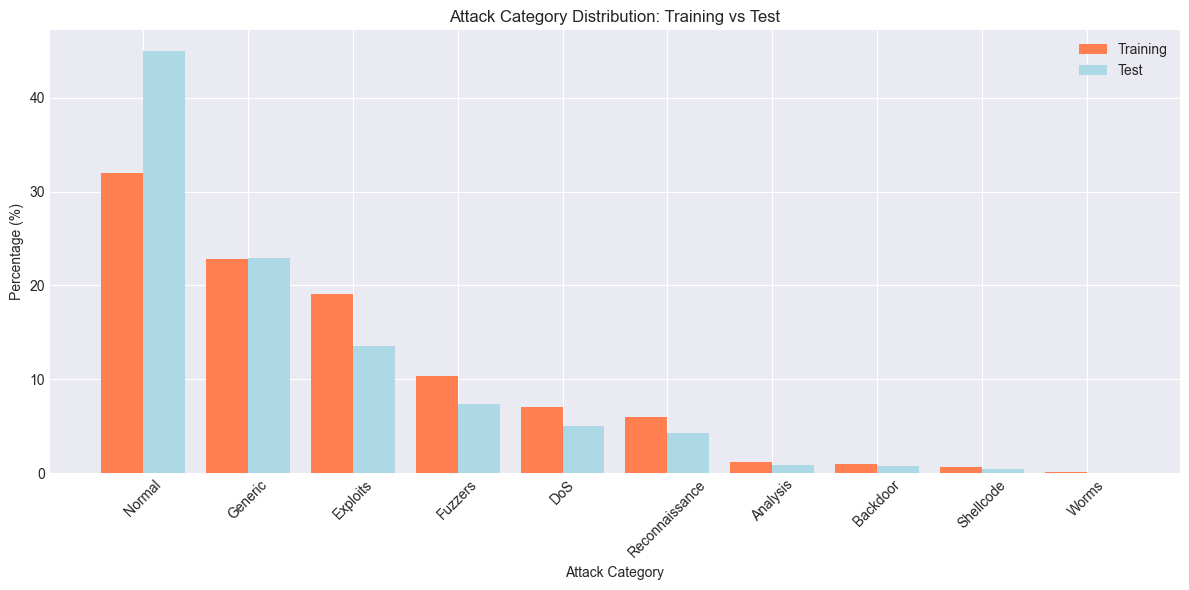

In [15]:
print("="*60)
print("ATTACK CATEGORY PERCENTAGES")
print("="*60)

# Calculate percentages
train_cat_pct = (train_df['attack_cat'].value_counts() / len(train_df)) * 100
test_cat_pct = (test_df['attack_cat'].value_counts() / len(test_df)) * 100

# Create comparison dataframe
cat_comparison = pd.DataFrame({
    'Training %': train_cat_pct,
    'Test %': test_cat_pct
}).fillna(0)

print("Attack category percentages:")
print(cat_comparison.round(2))

# Visualize
plt.figure(figsize=(12, 6))
x = range(len(cat_comparison.index))
plt.bar(x, cat_comparison['Training %'], width=0.4, label='Training', color='coral', align='center')
plt.bar([i + 0.4 for i in x], cat_comparison['Test %'], width=0.4, label='Test', color='lightblue', align='center')
plt.xlabel('Attack Category')
plt.ylabel('Percentage (%)')
plt.title('Attack Category Distribution: Training vs Test')
plt.xticks([i + 0.2 for i in x], cat_comparison.index, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

FEATURE RANGES CHECK
Feature ranges (notice the huge differences!):
        dur       sbytes       dbytes            rate         sload  \
Min    0.00        28.00         0.00        0.000000  0.000000e+00   
Max   60.00  12965233.00  14655550.00  1000000.000000  5.988000e+09   
Mean   1.36      8844.84     14928.92    95406.179688  7.345403e+07   
Std    6.48    174765.64    143654.22   165400.968750  1.883574e+08   

             dload  
Min   0.000000e+00  
Max   2.242273e+07  
Mean  6.712056e+05  
Std   2.421312e+06  


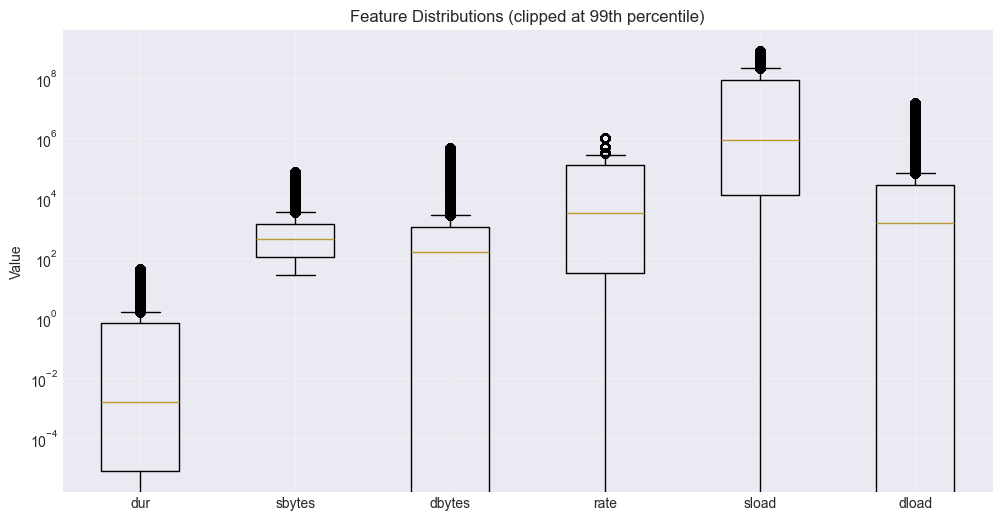

In [16]:
print("="*60)
print("FEATURE RANGES CHECK")
print("="*60)

# Select a few important numerical features
key_features = ['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload']

range_df = pd.DataFrame()
for feat in key_features:
    range_df.loc['Min', feat] = train_df[feat].min()
    range_df.loc['Max', feat] = train_df[feat].max()
    range_df.loc['Mean', feat] = train_df[feat].mean()
    range_df.loc['Std', feat] = train_df[feat].std()

print("Feature ranges (notice the huge differences!):")
print(range_df.round(2))

# Visualize the scale differences
plt.figure(figsize=(12, 6))
plt.boxplot([train_df[feat].clip(upper=train_df[feat].quantile(0.99)) for feat in key_features])
plt.xticks(range(1, len(key_features)+1), key_features)
plt.title('Feature Distributions (clipped at 99th percentile)')
plt.ylabel('Value')
plt.yscale('log')  # Log scale to see differences
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
svm_params = {
    'C': [0.1, 1, 10, 100],        # Regularization
    'kernel': ['rbf', 'linear'],    # Kernel type
    'gamma': ['scale', 'auto', 0.01, 0.1]  # Kernel coefficient
}

In [18]:
cnn_params = {
    'learning_rate': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'epochs': [50, 100],
    'num_layers': [2, 3, 4],
    'neurons': [64, 128, 256]
}

In [19]:
print("="*60)
print("HYPERPARAMETER INSIGHTS")
print("="*60)

print("Based on your data characteristics:")

# Check data size
print(f"\n Data size: {len(train_df):,} rows")
print("  → SVM might be slow with >100k rows (consider using LinearSVM or sampling)")
print("  → CNN can handle this well with batch training")

# Check feature count
print(f"\n Feature count: {len(numerical_cols) + len(categorical_cols)} features")
print("  → SVM works well with this many features")
print("  → CNN will need appropriate input layer size")

# Check class imbalance
normal_pct = (train_df['label']==0).sum()/len(train_df)*100
attack_pct = (train_df['label']==1).sum()/len(train_df)*100
print(f"\n  Class balance: Normal={normal_pct:.1f}%, Attack={attack_pct:.1f}%")
if abs(normal_pct - attack_pct) > 20:
    print("  → Imbalance detected! May need class_weight hyperparameter")
    
print("\n Hyperparameters will be tuned in Phase 4!")

HYPERPARAMETER INSIGHTS
Based on your data characteristics:

 Data size: 175,341 rows
  → SVM might be slow with >100k rows (consider using LinearSVM or sampling)
  → CNN can handle this well with batch training

 Feature count: 35 features
  → SVM works well with this many features
  → CNN will need appropriate input layer size

  Class balance: Normal=31.9%, Attack=68.1%
  → Imbalance detected! May need class_weight hyperparameter

 Hyperparameters will be tuned in Phase 4!


In [23]:
# Check what variables are currently defined
print("Variables in current notebook:")
print([var for var in dir() if not var.startswith('_')])

# Check if we have the data we need
if 'X_train' in dir():
    print(f"\n X_train exists with shape: {X_train.shape}")
else:
    print("\n X_train not found!")

if 'X_val' in dir():
    print(f" X_val exists with shape: {X_val.shape}")
else:
    print(" X_val not found!")

if 'X_test' in dir():
    print(f" X_test exists with shape: {X_test.shape}")
else:
    print(" X_test not found!")

Variables in current notebook:
['In', 'Out', 'PS1', 'REPLHooks', 'X_train', 'X_train_full', 'X_val', 'attack_pct', 'axes', 'cat_comparison', 'categorical_cols', 'cnn_params', 'col', 'downloads_path', 'exit', 'f', 'feat', 'fig', 'file', 'get_ipython', 'get_last_command', 'is_wsl', 'key_features', 'missing', 'normal_pct', 'np', 'numerical_cols', 'open', 'original_ps1', 'os', 'pd', 'platform', 'plt', 'processed_path', 'quit', 'range_df', 'sns', 'svm_params', 'sys', 'test_attack', 'test_attacks', 'test_cat_pct', 'test_df', 'test_file', 'test_normal', 'test_pct', 'total', 'train_attack', 'train_attacks', 'train_cat_pct', 'train_df', 'train_normal', 'train_pct', 'train_test_split', 'unique_count', 'warnings', 'x', 'y_train', 'y_train_full', 'y_val']

 X_train exists with shape: (122738, 34)
 X_val exists with shape: (52603, 34)
 X_test not found!
